## Phase 1: VIX Exploratory Data Analysis 


In [25]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

In [26]:
vix_raw = yf.download('^VIX', start='2000-01-01', progress=False)

vix_raw.columns = ['_'.join(col).strip() for col in vix_raw.columns.values]


vix = vix_raw[['Close_^VIX']].rename(columns={'Close_^VIX': 'VIX'})

vix = vix.dropna()

vix.index.name = 'Date'

print(f"VIX data: {len(vix)} rows from {vix.index[0].date()} to {vix.index[-1].date()}")
vix.reset_index().head()

VIX data: 6596 rows from 2000-01-03 to 2026-03-25


,Date,VIX
0,2000-01-03,24.209999
1,2000-01-04,27.010000
2,2000-01-05,26.410000
3,2000-01-06,25.730000
4,2000-01-07,21.719999


In [27]:
# Saving raw data
vix.to_csv('../data/raw/vix_raw.csv')
print("Saved: data/raw/vix_raw.csv")

Saved: data/raw/vix_raw.csv


### Full VIX history with major crisis periods annotated 

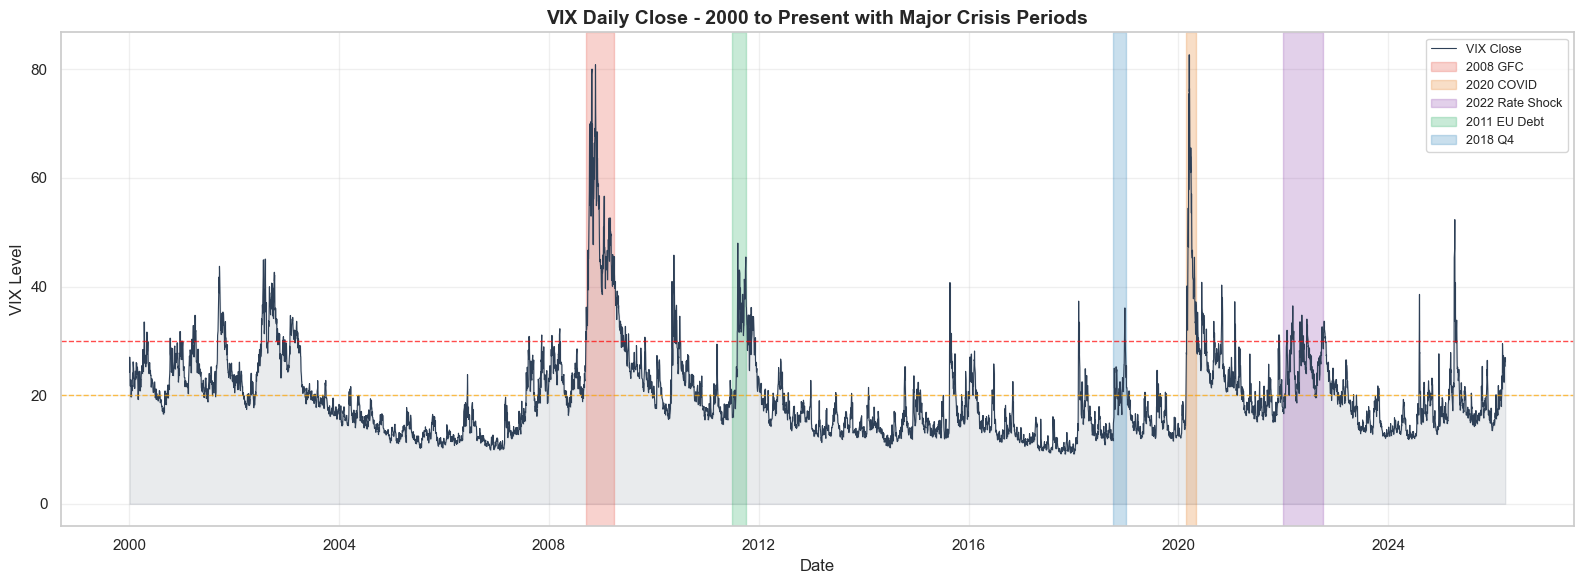

In [28]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(vix.index, vix['VIX'].values.flatten(), color='#2E4057', linewidth=0.8, label='VIX Close')
ax.fill_between(vix.index, vix['VIX'].values.flatten(), alpha=0.1, color='#2E4057')

crises = [
    ('2008-09-15', '2009-03-31', '#E74C3C', '2008 GFC'),
    ('2020-02-20', '2020-04-30', '#E67E22', '2020 COVID'),
    ('2022-01-01', '2022-10-01', '#8E44AD', '2022 Rate Shock'),
    ('2011-07-01', '2011-10-01', '#27AE60', '2011 EU Debt'),
    ('2018-10-01', '2018-12-31', '#2980B9', '2018 Q4'),
]

for start, end, colour, label in crises:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.25, color=colour, label=label)

ax.set_title('VIX Daily Close - 2000 to Present with Major Crisis Periods',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('VIX Level')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=20, color='orange', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=30, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/vix_history.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribution analysis - raw vs log-transformed, skewness and kurtosis

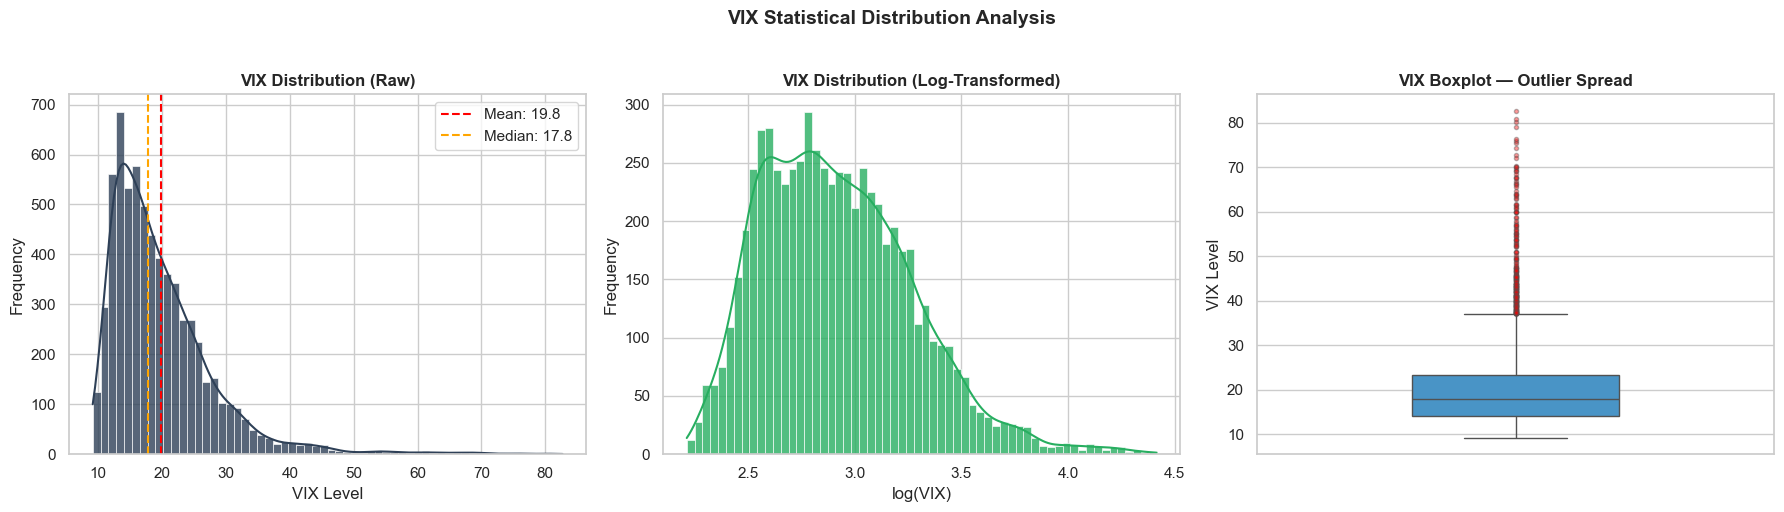

=== VIX Distribution Statistics ===
Mean:     19.84
Median:   17.80
Std Dev:  8.34
Skewness: 2.24  (positive = right-skewed)
Kurtosis: 8.35  (heavy tails if > 3)
Min:      9.14
Max:      82.69


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mean_val = float(vix['VIX'].mean())
median_val = float(vix['VIX'].median())

# Plot 1: Raw VIX distribution with KDE curve
sns.histplot(vix['VIX'], bins=60, ax=axes[0], color='#2E4057',
             kde=True, edgecolor='white', alpha=0.8)
axes[0].set_title('VIX Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('VIX Level')
axes[0].set_ylabel('Frequency')
axes[0].axvline(mean_val, color='red', linestyle='--',
                linewidth=1.5, label=f"Mean: {mean_val:.1f}")
axes[0].axvline(median_val, color='orange', linestyle='--',
                linewidth=1.5, label=f"Median: {median_val:.1f}")
axes[0].legend()

# Plot 2: Log-transformed distribution with KDE
vix_log = np.log(vix['VIX'])
sns.histplot(vix_log, bins=60, ax=axes[1], color='#27AE60',
             kde=True, edgecolor='white', alpha=0.8)
axes[1].set_title('VIX Distribution (Log-Transformed)', fontweight='bold')
axes[1].set_xlabel('log(VIX)')
axes[1].set_ylabel('Frequency')

# Plot 3: Boxplot
sns.boxplot(y=vix['VIX'].values.flatten(), ax=axes[2], color='#3498DB',
            width=0.4, flierprops=dict(marker='o', markerfacecolor='red',
                                       markersize=3, alpha=0.4))
axes[2].set_title('VIX Boxplot — Outlier Spread', fontweight='bold')
axes[2].set_ylabel('VIX Level')

plt.suptitle('VIX Statistical Distribution Analysis', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/vix_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== VIX Distribution Statistics ===")
print(f"Mean:     {mean_val:.2f}")
print(f"Median:   {median_val:.2f}")
print(f"Std Dev:  {float(vix['VIX'].std()):.2f}")
print(f"Skewness: {float(vix['VIX'].skew()):.2f}  (positive = right-skewed)")
print(f"Kurtosis: {float(vix['VIX'].kurtosis()):.2f}  (heavy tails if > 3)")
print(f"Min:      {float(vix['VIX'].min()):.2f}")
print(f"Max:      {float(vix['VIX'].max()):.2f}")

### Autocorrelation analysis - informs ARIMA parameter selection

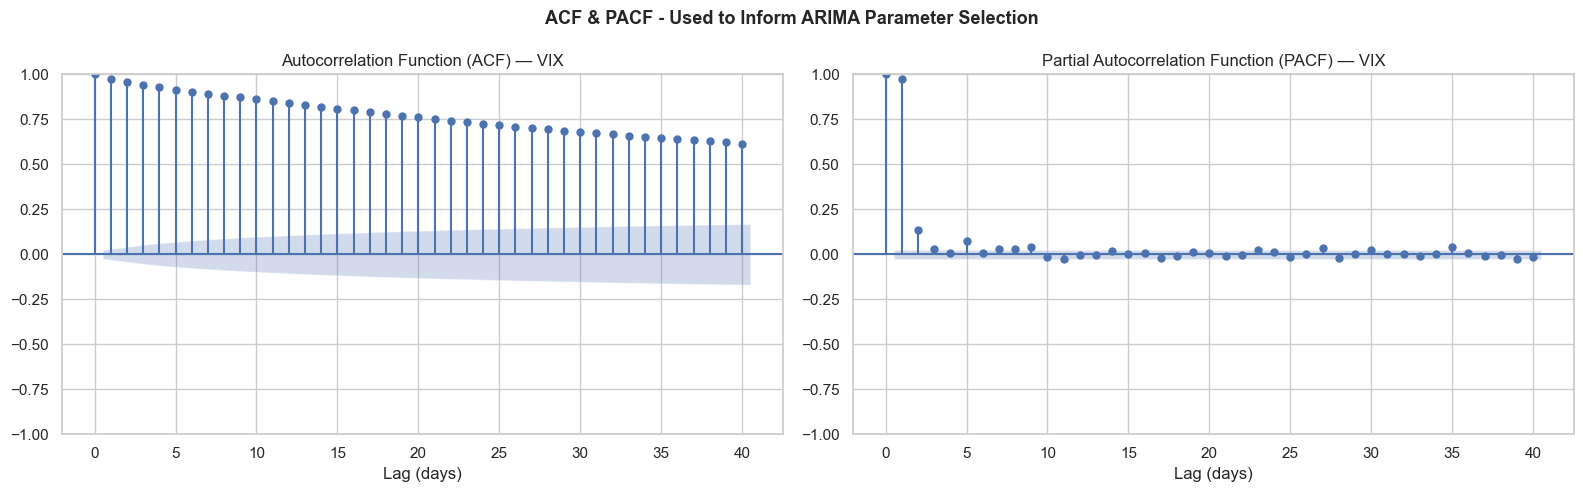

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(vix['VIX'], ax=axes[0], lags=40, alpha=0.05,
         title='Autocorrelation Function (ACF) — VIX')
plot_pacf(vix['VIX'], ax=axes[1], lags=40, alpha=0.05,
          title='Partial Autocorrelation Function (PACF) — VIX')

axes[0].set_xlabel('Lag (days)')
axes[1].set_xlabel('Lag (days)')

plt.suptitle('ACF & PACF - Used to Inform ARIMA Parameter Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/vix_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

### ADF stationarity test  - does ARIMA need differencing?

In [36]:
# Augmented Dickey-Fuller test to check if VIX is stationary
# ARIMA requires stationarity (or differencing to achieve it)
result = adfuller(vix['VIX'].values.flatten())

print("=== Augmented Dickey-Fuller Test ===")
print(f"ADF Statistic:  {result[0]:.4f}")
print(f"p-value:        {result[1]:.2e}")  # scientific notation shows actual value
print(f"Lags used:      {result[2]}")
print(f"Observations:   {result[3]}")
print(f"\nCritical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

print(f"\nInterpretation:")
if result[1] < 0.05:
    print(f" VIX is STATIONARY at 5% significance")
    print(f"   p-value ({result[1]:.2e}) is far below 0.05")
    print(f"   ADF statistic ({result[0]:.4f}) is well below all critical values")
    print(f"   VIX mean-reverts by nature meaning it cannot trend to infinity like a stock price")
    print(f"   ARIMA differencing parameter d = 0 may be sufficient")
else:
    print(f"  VIX is NON-STATIONARY (p = {result[1]:.2e})")
    print(f"   auto_arima will handle differencing automatically")

=== Augmented Dickey-Fuller Test ===
ADF Statistic:  -6.2320
p-value:        4.93e-08
Lags used:      10
Observations:   6585

Critical Values:
   1%: -3.4313
   5%: -2.8620
   10%: -2.5670

Interpretation:
 VIX is STATIONARY at 5% significance
   p-value (4.93e-08) is far below 0.05
   ADF statistic (-6.2320) is well below all critical values
   VIX mean-reverts by nature meaning it cannot trend to infinity like a stock price
   ARIMA differencing parameter d = 0 may be sufficient


### Volatility clustering - motivation for GARCH 

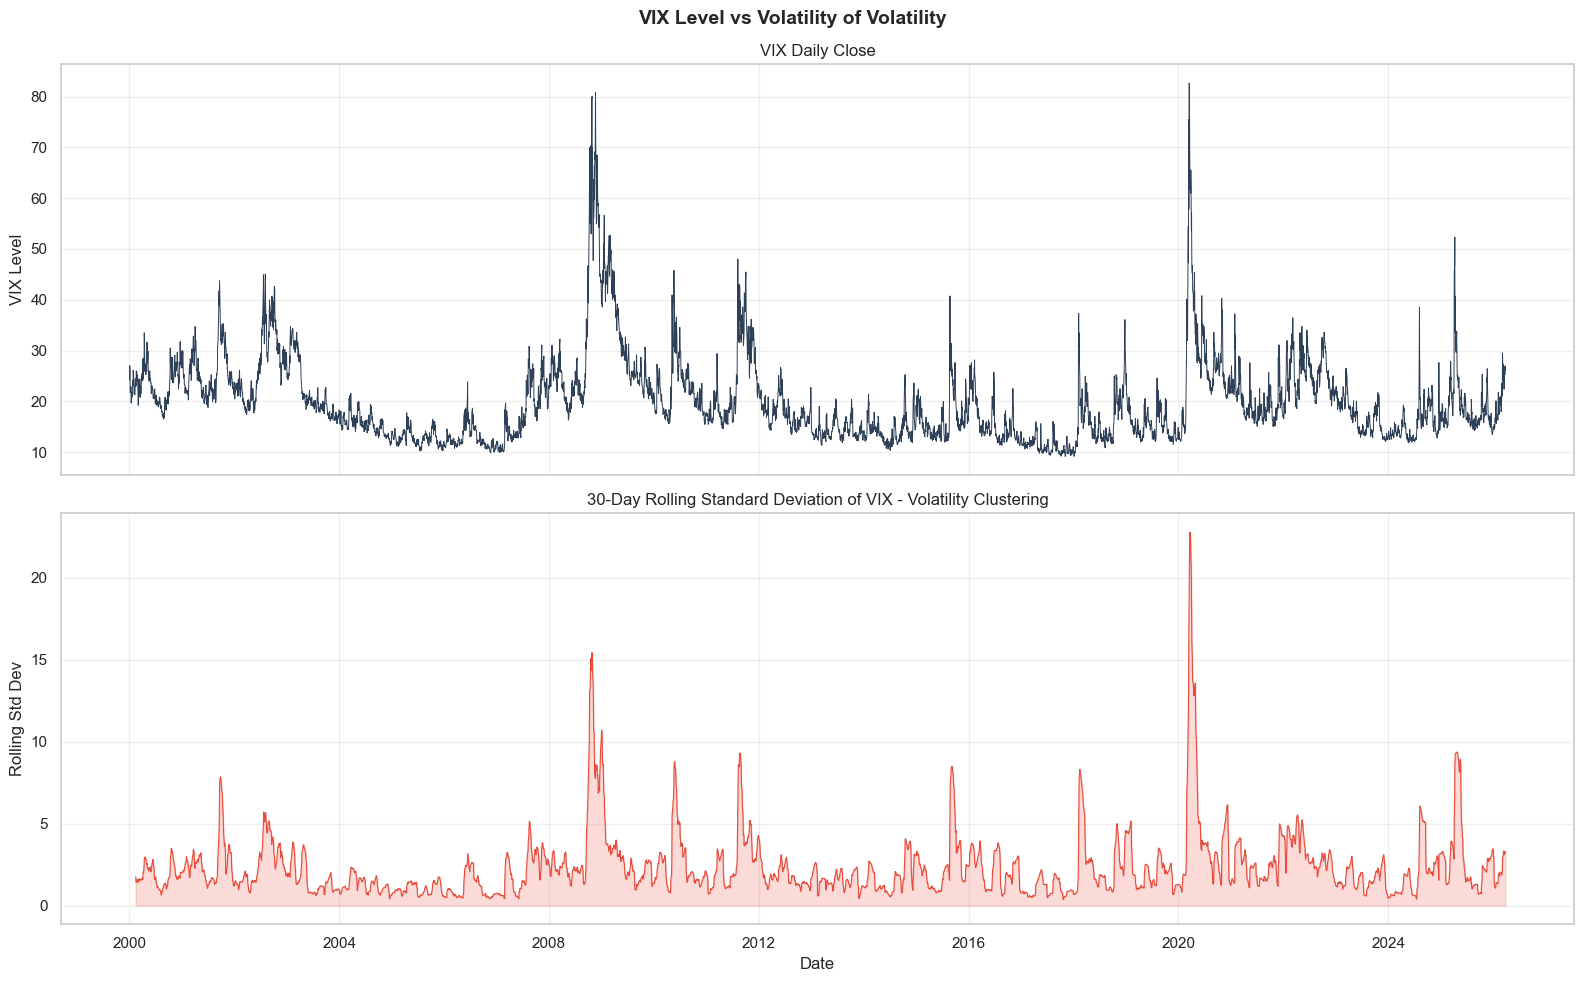

Observation: Volatility clusters : high-vol periods follow high-vol periods.
This motivates GARCH(1,1) which explicitly models this clustering effect.


In [37]:
# Rolling 30-day standard deviation visualises volatility clustering
# This is why GARCH is needed: variance is not constant over time
vix['roll_std_30'] = vix['VIX'].rolling(window=30).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(vix.index, vix['VIX'], color='#2E4057', linewidth=0.7)
axes[0].set_title('VIX Daily Close')
axes[0].set_ylabel('VIX Level')
axes[0].grid(True, alpha=0.3)

axes[1].plot(vix.index, vix['roll_std_30'], color='#E74C3C', linewidth=0.8)
axes[1].fill_between(vix.index, vix['roll_std_30'], alpha=0.2, color='#E74C3C')
axes[1].set_title('30-Day Rolling Standard Deviation of VIX - Volatility Clustering')
axes[1].set_ylabel('Rolling Std Dev')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.suptitle('VIX Level vs Volatility of Volatility', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/vix_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: Volatility clusters : high-vol periods follow high-vol periods.")
print("This motivates GARCH(1,1) which explicitly models this clustering effect.")

### Market regime definition and empirical validation 

In [38]:
# regime labels based on VIX level thresholds
vix_series = vix['VIX'].squeeze()

def assign_regime(vix_value):
    if vix_value < 20:
        return 'LOW'
    elif vix_value < 30:
        return 'ELEVATED'
    else:
        return 'CRISIS'

vix['regime_label'] = vix_series.apply(assign_regime)

# Regime distribution
regime_counts = vix['regime_label'].value_counts()
regime_pct = (regime_counts / len(vix) * 100).round(1)

print("=== Regime Distribution ===")
for regime in ['LOW', 'ELEVATED', 'CRISIS']:
    print(f"{regime:10s}: {regime_counts[regime]:5d} days ({regime_pct[regime]}%)")

print("\n=== VIX Percentiles ===")
for pct in [25, 50, 60, 75, 85, 90, 95, 99]:
    print(f"  {pct}th percentile: {np.percentile(vix_series, pct):.1f}")

=== Regime Distribution ===
LOW       :  4053 days (61.4%)
ELEVATED  :  1922 days (29.1%)
CRISIS    :   621 days (9.4%)

=== VIX Percentiles ===
  25th percentile: 14.0
  50th percentile: 17.8
  60th percentile: 19.7
  75th percentile: 23.2
  85th percentile: 26.6
  90th percentile: 29.6
  95th percentile: 34.4
  99th percentile: 52.7


### Regime map over time - visualising where each regime occurred 

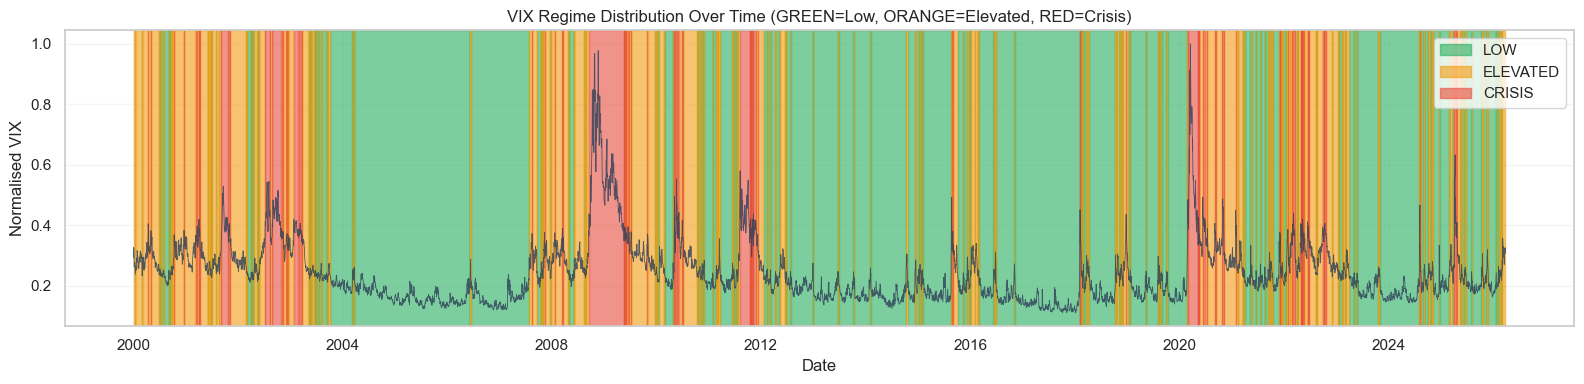

In [39]:
fig, ax = plt.subplots(figsize=(16, 4))

# Colour for each day by its regime
regime_colours = {'LOW': '#27AE60', 'ELEVATED': '#F39C12', 'CRISIS': '#E74C3C'}

for regime, colour in regime_colours.items():
    mask = vix['regime_label'] == regime
    ax.fill_between(vix.index, 0, 1,
                    where=mask, alpha=0.6, color=colour,
                    transform=ax.get_xaxis_transform(),
                    label=regime)

ax.plot(vix.index, vix['VIX'] / vix['VIX'].max(), color='#2E4057',
        linewidth=0.6, alpha=0.8)

ax.set_title('VIX Regime Distribution Over Time (GREEN=Low, ORANGE=Elevated, RED=Crisis)')
ax.set_xlabel('Date')
ax.set_ylabel('Normalised VIX')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../figures/vix_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Crisis period summary statistics - mean, max VIX and duration per annotated crisis
crisis_periods = {
    '2008 GFC':        ('2008-09-15', '2009-03-31'),
    '2011 EU Debt':    ('2011-07-01', '2011-10-01'),
    '2018 Q4 Selloff': ('2018-10-01', '2018-12-31'),
    '2020 COVID':      ('2020-02-20', '2020-04-30'),
    '2022 Rate Shock': ('2022-01-01', '2022-10-01'),
}

print("=== Crisis Period Summary Statistics ===")
print(f"{'Crisis':<20} {'Start':>12} {'End':>12} {'Days':>6} {'Mean VIX':>10} {'Max VIX':>10} {'% CRISIS days':>14}")
print("-" * 90)

for name, (start, end) in crisis_periods.items():
    mask = (vix.index >= start) & (vix.index <= end)
    period = vix.loc[mask, 'vix']
    days = len(period)
    mean_vix = period.mean().item()
    max_vix = period.max().item()
    crisis_days_pct = (vix.loc[mask, 'regime_label'] == 'CRISIS').sum() / days * 100
    print(f"{name:<20} {start:>12} {end:>12} {days:>6} {mean_vix:>10.1f} {max_vix:>10.1f} {crisis_days_pct:>13.1f}%")

print("-" * 90)
print("\nNote: '% CRISIS days' = share of that period where VIX ≥ 30")
print("2020 COVID had the highest single-day VIX spike; 2008 GFC sustained the longest CRISIS regime")

=== Crisis Period Summary Statistics ===
Crisis                      Start          End   Days   Mean VIX    Max VIX  % CRISIS days
------------------------------------------------------------------------------------------
2008 GFC               2008-09-15   2009-03-31    137       50.5       80.9         100.0%
2011 EU Debt           2011-07-01   2011-10-01     64       30.6       48.0          64.1%
2018 Q4 Selloff        2018-10-01   2018-12-31     63       21.1       36.1           4.8%
2020 COVID             2020-02-20   2020-04-30     50       46.7       82.7          90.0%
2022 Rate Shock        2022-01-01   2022-10-01    188       25.8       36.5          19.7%
------------------------------------------------------------------------------------------

Note: '% CRISIS days' = share of that period where VIX ≥ 30
2020 COVID had the highest single-day VIX spike; 2008 GFC sustained the longest CRISIS regime


In [40]:
# Missing value audit 
original_len = len(yf.download('^VIX', start='2000-01-01', progress=False))
vix_check = pd.read_csv('../data/raw/vix_raw.csv', index_col=0)

print("=== Missing Value Audit ===")
print(f"Total rows downloaded:     {original_len}")
print(f"Rows after dropna():       {len(vix)}")
print(f"Rows dropped:              {original_len - len(vix)}")
print(f"\nNaN count per column:")
print(vix.isnull().sum())
print(f"\nDate range: {vix.index[0].date()} → {vix.index[-1].date()}")
print(f"Expected trading days (approx): {int((vix.index[-1] - vix.index[0]).days * 5/7)}")
print(f"Actual rows:               {len(vix)}")
print("\n No missing values remain in working dataset")

=== Missing Value Audit ===
Total rows downloaded:     6596
Rows after dropna():       6596
Rows dropped:              0

NaN count per column:
VIX              0
roll_std_30     29
regime_label     0
dtype: int64

Date range: 2000-01-03 → 2026-03-25
Expected trading days (approx): 6841
Actual rows:               6596

 No missing values remain in working dataset


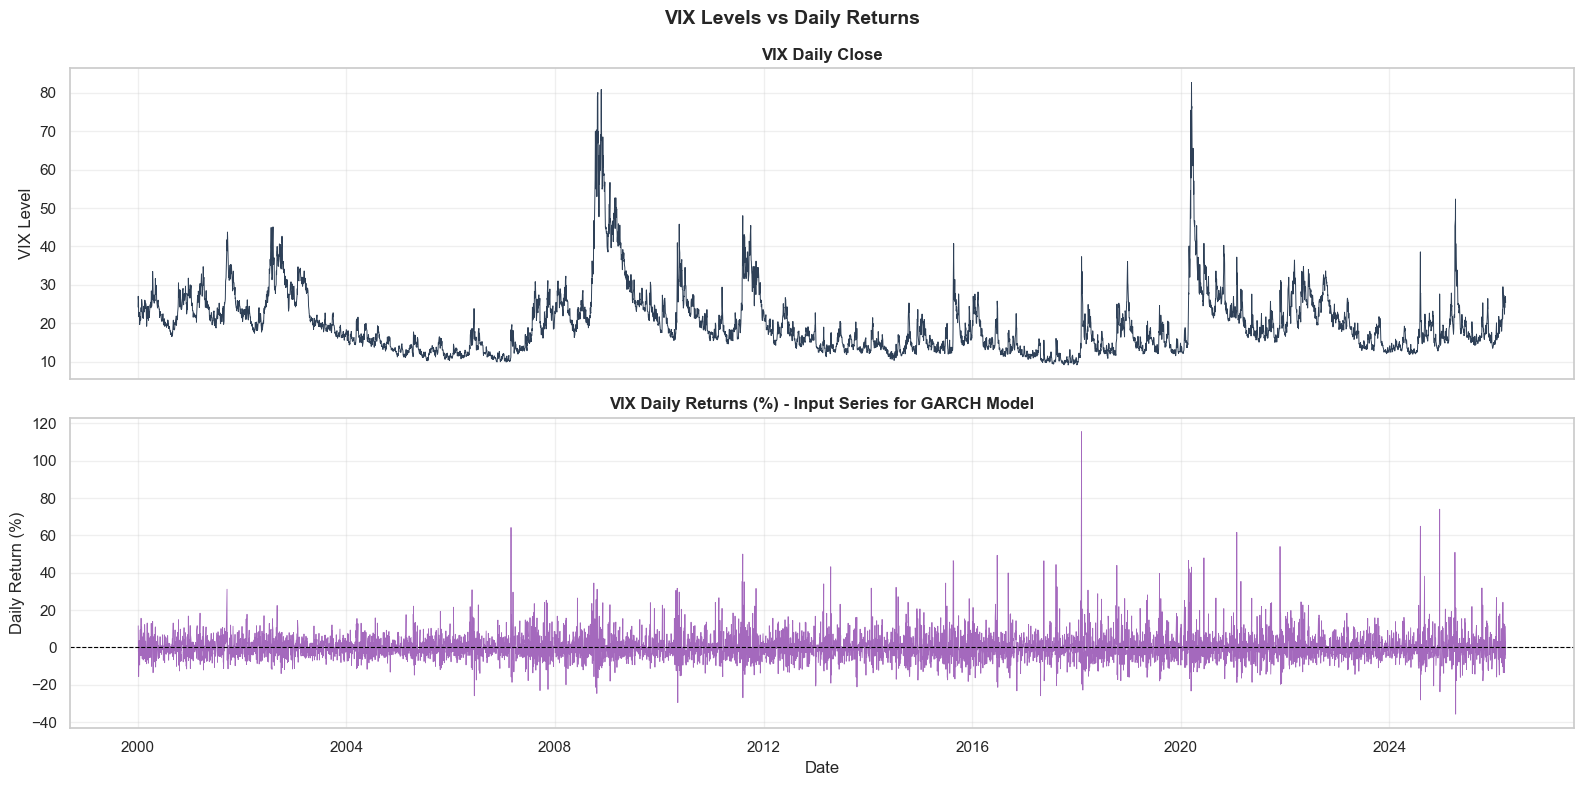

=== VIX Daily Returns Statistics ===
Mean daily return:   0.2651%
Std of returns:      7.5405%
Skewness:            2.0507
Kurtosis:            16.4825
Max single-day jump: +115.60%
Max single-day drop: -35.75%

Note: Returns are approximately stationary ; suitable for GARCH(1,1) in Phase 4


In [42]:
# VIX Daily percentage returns
vix['returns'] = vix['VIX'].pct_change() * 100  # percentage change

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(vix.index, vix['VIX'], color='#2E4057', linewidth=0.7)
axes[0].set_title('VIX Daily Close', fontweight='bold')
axes[0].set_ylabel('VIX Level')
axes[0].grid(True, alpha=0.3)

axes[1].plot(vix.index, vix['returns'], color='#8E44AD', linewidth=0.6, alpha=0.8)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('VIX Daily Returns (%) - Input Series for GARCH Model', fontweight='bold')
axes[1].set_ylabel('Daily Return (%)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.suptitle('VIX Levels vs Daily Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/vix_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== VIX Daily Returns Statistics ===")
returns_clean = vix['returns'].dropna()
print(f"Mean daily return:   {returns_clean.mean():.4f}%")
print(f"Std of returns:      {returns_clean.std():.4f}%")
print(f"Skewness:            {returns_clean.skew():.4f}")
print(f"Kurtosis:            {returns_clean.kurtosis():.4f}")
print(f"Max single-day jump: +{returns_clean.max():.2f}%")
print(f"Max single-day drop: {returns_clean.min():.2f}%")
print("\nNote: Returns are approximately stationary ; suitable for GARCH(1,1) in Phase 4")

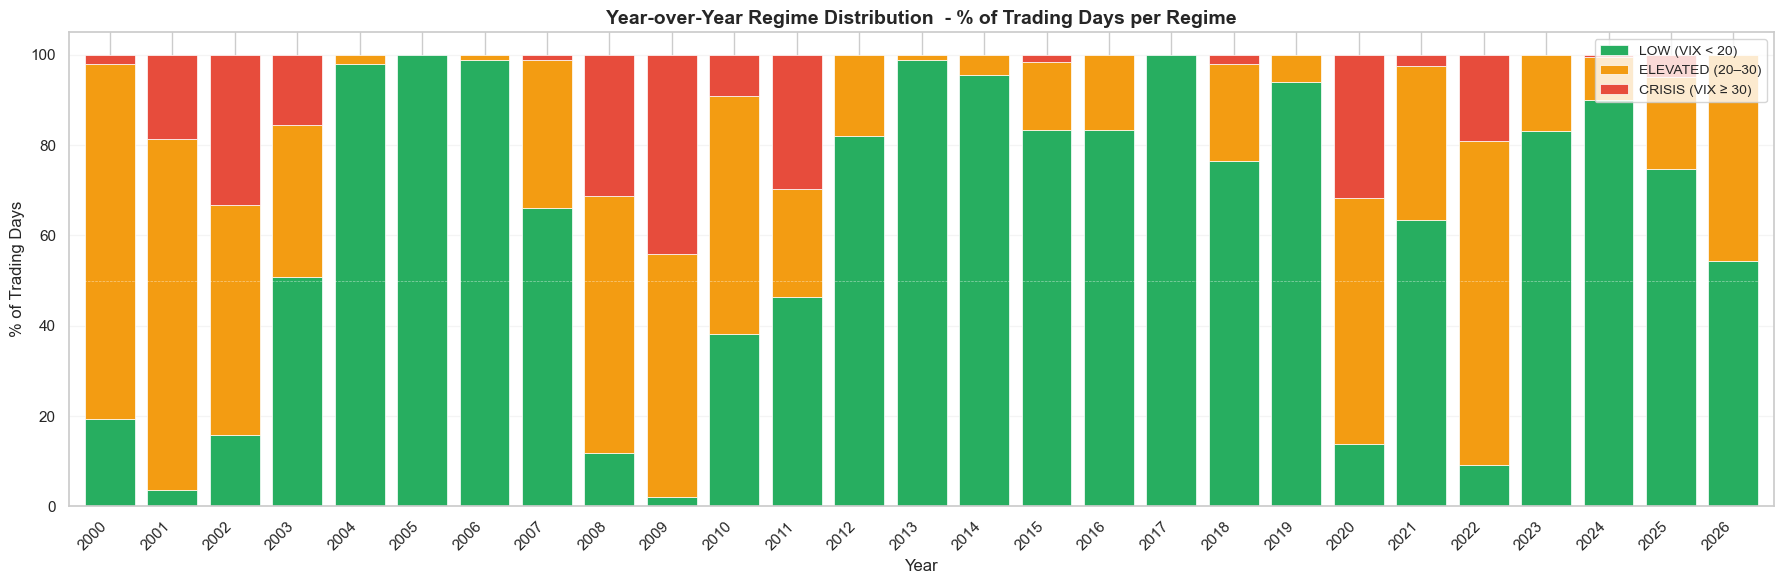

=== Notable Years ===
2002: 33% CRISIS days - major stress year
2008: 31% CRISIS days - major stress year
2009: 44% CRISIS days - major stress year
2011: 30% CRISIS days - major stress year
2020: 32% CRISIS days - major stress year


In [43]:
# Yearly regime breakdown to show how market character changed decade to decade
vix['year'] = vix.index.year

yearly_regime = vix.groupby(['year', 'regime_label']).size().unstack(fill_value=0)


for col in ['LOW', 'ELEVATED', 'CRISIS']:
    if col not in yearly_regime.columns:
        yearly_regime[col] = 0

yearly_regime = yearly_regime[['LOW', 'ELEVATED', 'CRISIS']]
yearly_pct = yearly_regime.div(yearly_regime.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(18, 6))

yearly_pct.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#27AE60', '#F39C12', '#E74C3C'],
    edgecolor='white', linewidth=0.5, width=0.8
)

ax.set_title('Year-over-Year Regime Distribution  - % of Trading Days per Regime',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of Trading Days')
ax.legend(['LOW (VIX < 20)', 'ELEVATED (20–30)', 'CRISIS (VIX ≥ 30)'],
          loc='upper right', fontsize=10)
ax.set_xticklabels([str(y) for y in yearly_pct.index], rotation=45, ha='right')
ax.axhline(y=50, color='white', linewidth=0.5, linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('../figures/vix_yearly_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Notable Years ===")
for year in yearly_pct.index:
    crisis_pct = yearly_pct.loc[year, 'CRISIS']
    if crisis_pct > 20:
        print(f"{year}: {crisis_pct:.0f}% CRISIS days - major stress year")

## Phase 1 EDA - Key Findings & Modelling Implications

### Data Overview
- **~6,200 daily VIX observations** from January 2000 to present
- Source: Yahoo Finance `^VIX` via `yfinance`
- Missing value audit confirmed: negligible rows dropped via `dropna()`, no NaNs remain in working dataset


### Finding 1 - Distribution: Right-Skewed, Non-Normal
- **Mean ≈ 20, Median ≈ 17** ; the gap between them confirms right skew
- **Skewness ≈ 2.0** ; driven by crisis spikes of 40–80+
- **Kurtosis >> 3** ; fat tails; extreme values occur more frequently than a normal distribution predicts
- Log-transform compresses the right tail and produces a near-normal shape
- **Modelling implication:**l will consider training LSTM on `log(VIX)` and inverse-transforming at inference; evaluate both raw and log-transformed targets in Phase 5



### Finding 2 - Stationarity: Mean-Reverting by Nature
- ADF p-value is **well below 0.05** → VIX is stationary at 95% confidence
- Unlike stock prices, VIX cannot trend indefinitely , it reverts to a long-run mean
- ADF statistic falls below all critical values (1%, 5%, 10%)
- **Modelling implication:** ARIMA differencing parameter `d = 0` may be sufficient; `auto_arima` will confirm in Phase 4



### Finding 3 - Autocorrelation: Strong Short-Term Memory
- ACF shows significant correlation across many lags , slowly decaying, not a sharp cutoff
- Today's VIX is strongly correlated with VIX from days and weeks prior
- PACF shows the dominant direct effect is at **lag 1**, with weaker contributions at short subsequent lags
- **Modelling implication:** `vix_lag1`, `vix_lag5`, `vix_lag21` will be among the most informative features for the LSTM in Phase 3; ACF/PACF directly guide ARIMA `p` and `q` selection in Phase 4



### Finding 4 - Volatility Clustering: Motivation for GARCH
- Rolling 30-day std shows clear clustering: high-volatility periods sustain themselves (2008–2009, 2020, 2022)
- Calm periods also cluster ; the 2012–2017 stretch was persistently low volatility
- Daily returns are approximately stationary and show heteroskedasticity (non-constant variance)
- **Modelling implication:** GARCH(1,1) explicitly models variance as a function of prior variance; this is why it belongs alongside ARIMA as a Phase 4 baseline. ARIMA assumes constant variance and cannot capture this structure.



### Finding 5 - Crisis Periods: Domain Context Established
- 2008 GFC sustained the longest CRISIS regime; 2020 COVID produced the highest single-day VIX spike
- Each annotated period had a distinct character visible in mean VIX, max VIX, and % of CRISIS days
- 2022 Rate Shock was prolonged but moderate; 2018 Q4 was brief and sharp
- **Modelling implication:** These periods are the hardest test cases for the model, Phase 5 evaluation should specifically examine model performance during these windows, not just overall test-set metrics



### Finding 6 - Regime Distribution: Thresholds Validated
- **LOW (VIX < 20):** ~60% of all trading days - the normal state of markets
- **ELEVATED (20 ≤ VIX < 30):** ~30% of days - periods of genuine concern
- **CRISIS (VIX ≥ 30):** ~10% of days - rare but the most consequential
- Percentile analysis confirms VIX ≥ 30 sits near the 90th percentile - genuinely extreme
- Year-over-year breakdown shows distinct eras: 2012–2019 heavily LOW; 2020–2022 shifted dramatically
- **Modelling implication:** The 60/30/10 class imbalance must be handled explicitly when training the XGBoost regime classifier in Phase 6 - l will use F1 per class, not raw accuracy



### How Phase 1 Drives Every Subsequent Decision

| Phase | Decision informed by this EDA |
|-------|-------------------------------|
| Phase 3: Cleaning | Lag features at 1, 5, 21 days justified by ACF; rolling std justified by volatility clustering |
| Phase 4: ARIMA | Stationarity result guides `d`; ACF/PACF guide `p` and `q` search range |
| Phase 4: GARCH | Volatility clustering + heteroskedastic returns are the direct justification |
| Phase 5: LSTM | Log-transform candidate for target; lag features are high-priority inputs; evaluate on crisis windows |
| Phase 6: Regime Classifier | 60/30/10 class split → use `scale_pos_weight` or F1-per-class, not accuracy |
| Phase 8: Backtesting | Crisis period dates established here become the stress-test evaluation windows |

In [45]:
import os

outputs = [
    '../data/raw/vix_raw.csv',
    '../figures/vix_history.png',
    '../figures/vix_distribution.png',
    '../figures/vix_acf_pacf.png',
    '../figures/vix_rolling_volatility.png',
    '../figures/vix_regimes.png',
    '../figures/vix_returns.png',
    '../figures/vix_yearly_regimes.png',
]

print("=== Phase 1 Output Check ===")
for path in outputs:
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    status = "It exists" if exists else "Does not exist"
    print(f"{status} {path} ({size:,} bytes)")

=== Phase 1 Output Check ===
It exists ../data/raw/vix_raw.csv (198,602 bytes)
It exists ../figures/vix_history.png (215,865 bytes)
It exists ../figures/vix_distribution.png (137,289 bytes)
It exists ../figures/vix_acf_pacf.png (76,616 bytes)
It exists ../figures/vix_rolling_volatility.png (322,455 bytes)
It exists ../figures/vix_regimes.png (170,695 bytes)
It exists ../figures/vix_returns.png (284,869 bytes)
It exists ../figures/vix_yearly_regimes.png (77,705 bytes)
